In [1]:
import torch
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments, ViTImageProcessor, BertTokenizer, VisionEncoderDecoderModel

import torch
from torch.utils.data import Dataset
import os
import cv2
import numpy as np

from PIL import Image, ImageFile
from tqdm import tqdm
import xml.etree.ElementTree as ET


import re

# Add ../ as a directory to import from
import sys
sys.path.append('../')

from plant_dataset import load_sideview_images
from image_process import process_leaf_image
from plant_tokenizer import vec2token, SOS_TOKEN, EOS_TOKEN, PAD_TOKEN, VOCAB_SIZE
from string_to_xml_to_vec import xml2vec, linked_to_recursive
from plant_dataset import PlantDataset


# 필요한 객체 불러오기
image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
model = VisionEncoderDecoderModel.from_encoder_decoder_pretrained(
    "google/vit-base-patch16-224-in21k", "google-bert/bert-base-uncased"
)
model.config.decoder_start_token_id = SOS_TOKEN
model.config.pad_token_id = PAD_TOKEN
model.config.vocab_size = VOCAB_SIZE

# Dataset 인스턴스 생성
growth_stages = ["01"]
dataset = PlantDataset(root_dir="../data/2000_Plots_20241210_Quantized", 
                        process_leaf=True,
                        stages=growth_stages, preload=False, image_processor=image_processor, add_sos_token=False)


Some weights of BertLMHeadModel were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['bert.encoder.layer.0.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.0.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.0.crossattention.output.dense.bias', 'bert.encoder.layer.0.crossattention.output.dense.weight', 'bert.encoder.layer.0.crossattention.self.key.bias', 'bert.encoder.layer.0.crossattention.self.key.weight', 'bert.encoder.layer.0.crossattention.self.query.bias', 'bert.encoder.layer.0.crossattention.self.query.weight', 'bert.encoder.layer.0.crossattention.self.value.bias', 'bert.encoder.layer.0.crossattention.self.value.weight', 'bert.encoder.layer.1.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.1.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.1.crossattention.output.dense.bias', 'bert.encoder.layer.1.crossattention.output.dense.weight', 'bert.encoder.layer.1.crossattention.self.key.bi

Total 2000 images and plant strings loaded


In [ ]:
# 훈련 인자 설정
exp_name = "vit-base-patch16-224-in21k"
training_args = TrainingArguments(
    output_dir=f'./log/{exp_name}/results',          # 모델 출력 디렉토리
    num_train_epochs=3,              # 훈련 에포크 수
    per_device_train_batch_size=2,   # 훈련 배치 사이즈
    per_device_eval_batch_size=2,    # 평가 배치 사이즈
    warmup_steps=500,                 # 학습률 스케줄러를 위한 웜업 스텝 수
    weight_decay=0.01,                # 가중치 감쇠
    logging_dir=f'./{exp_name}',            # 로그 디렉토리
    logging_steps=10,
)

# Trainer 객체 생성
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    eval_dataset=dataset,  # 평가 데이터셋 (여기서는 동일한 데이터셋 사용)
)

# 모델 학습
trainer.train()

# 모델 저장
trainer.save_model(f'./log/{exp_name}/results')

In [2]:
# # inference (generation)
checkpoint_path = "../log/20250321_Quantized_dataset_PlantMeta/results"
model = VisionEncoderDecoderModel.from_pretrained(checkpoint_path)
model.config.decoder_start_token_id = SOS_TOKEN
model.config.bos_token_id = SOS_TOKEN
model.config.eos_token_id = EOS_TOKEN
model.config.pad_token_id = PAD_TOKEN
# Set the model to evaluation mode
model.eval()

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_featur

tensor([[87, 88, 69, 76, 76, 88,  0, 73, 77, 83, 72, 72,  1, 52, 40, 35, 81,  2,
         35, 36, 78, 31, 72,  3, 49, 73, 35, 33,  6, 35, 35, 79, 72, 73,  7, 47,
         40, 76, 81,  8, 54, 38, 77, 28, 71,  9, 54, 34, 74, 33, 10, 54, 74, 35,
         33, 11, 54, 73, 34, 33,  7, 37, 40, 76, 82,  8, 44, 35, 77, 28, 71,  9,
         44, 35, 74, 33, 10, 45, 35, 35, 33, 11, 44, 35, 34, 33,  2, 35, 36, 78,
         31, 72,  3, 49, 73, 35, 33, 90]])
tensor([[87, 88, 68, 77, 77, 88,  0, 67, 78, 80, 72, 72,  1, 52, 40, 35, 82,  2,
         35, 36, 78, 31, 72,  3, 49, 67, 35, 33,  6, 35, 35, 79, 72, 73,  7, 47,
         40, 76, 82,  8, 54, 38, 77, 31, 71,  9, 55, 33, 74, 33, 10, 55, 35, 35,
         33, 11, 55, 33, 34, 33,  7, 37, 40, 76, 82,  8, 44, 35, 77, 28, 71,  9,
         44, 74, 74, 33, 10, 45, 33, 35, 33, 11, 44, 35, 34, 33,  2, 35, 36, 78,
         31, 72,  3, 49, 63, 35, 33, 90]])


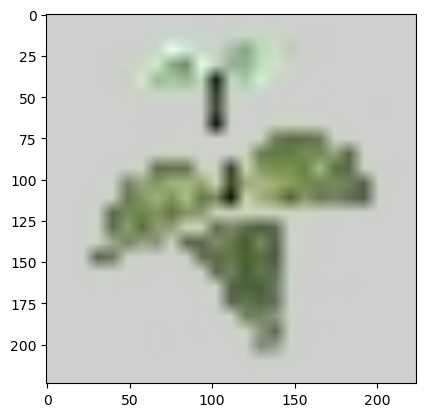

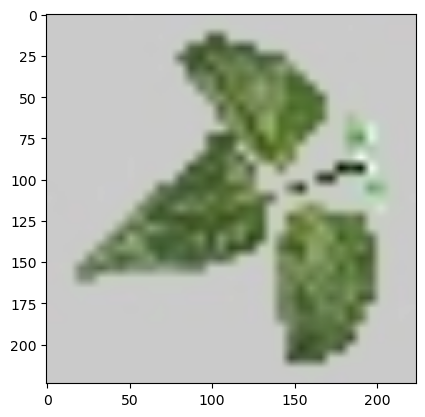

In [3]:
import matplotlib.pyplot as plt
for i in range(2):
    pixel_values = dataset[i]["pixel_values"].unsqueeze(0).to(model.device)
    plant_info = dataset[i]["plant_info"]
    plant_info = torch.tensor(plant_info, dtype=torch.long).unsqueeze(0).to(model.device)  # Ensure plant_info is a tens
    generated_ids = model.generate(pixel_values,
                                decoder_start_token_id=SOS_TOKEN,
                                decoder_input_ids=plant_info,
                                eos_token_id=EOS_TOKEN,
                                max_length=200
                                )
    print(generated_ids)

    image_vis = pixel_values.squeeze().permute(1,2,0).cpu().numpy()
    image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    plt.figure()
    plt.imshow(image_vis)


Save dir: /home/lion397/codes/Image2PlantArchitecture/src/temp
Output name: plant_0_gt
Debug: false
Grow: false
View height: 1m
Tile file: none
Loading plant architecture XML file: /home/lion397/codes/Image2PlantArchitecture/src/temp/plant_0_gt.xml...done.
Plant Height: 0.0235895
Stem Height: 0.00804005
Leaf count: 8
Leaf area: 0.000116701
Leaf inclination: 0.0736183 0.19946 0.13773 0.0657363 0.233904 0.221898 0.0231393 0.0242339 0.016947 0.0033328 


Save dir: /home/lion397/codes/Image2PlantArchitecture/src/temp
Output name: plant_0_est
Debug: false
Grow: false
View height: 1m
Tile file: none
Loading plant architecture XML file: /home/lion397/codes/Image2PlantArchitecture/src/temp/plant_0_est.xml...done.
Plant Height: 0.0235895
Stem Height: 0.00804005
Leaf count: 8
Leaf area: 0.000116701
Leaf inclination: 0.0736183 0.19946 0.13773 0.0657363 0.233904 0.221898 0.0231393 0.0242339 0.016947 0.0033328 


Save dir: /home/lion397/codes/Image2PlantArchitecture/src/temp
Output name: plant_1_gt

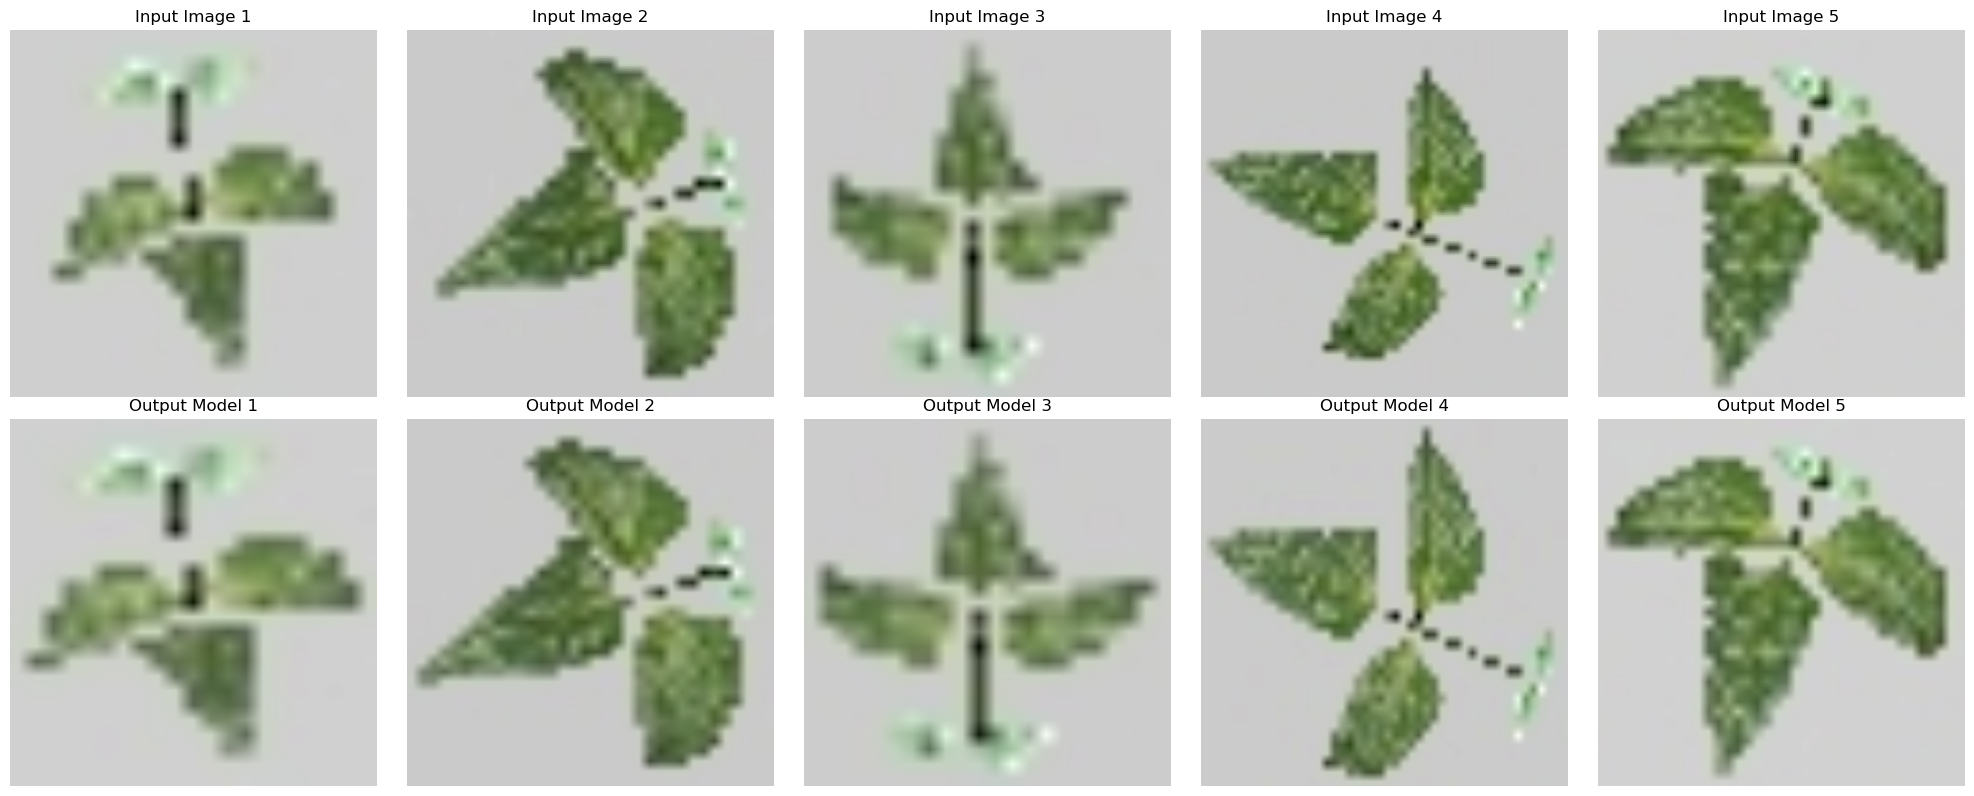

In [6]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plant_tokenizer import SOS_TOKEN, EOS_TOKEN
from models.model import get_tgt_mask
from plant_dataset import PlantDataset, load_sideview_images
from image_process import process_leaf_image
from plantstring2model import plantstring2model
from string_to_xml_to_vec import vec2xml, recursive_to_linked
from plant_tokenizer import token2vec
import subprocess
import shutil
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml

  
program_path = "../src/GenerateDataset/build"
# Function to re-render a single XML file
def re_render_xml(output_path, filename, rotation=True):
    image_name = filename.split("/")[-1].split(".")[0]
    os.environ["DISPLAY"] = ":11.0"
    #os.environ["DISPLAY"] = ":1.0"
    # Generate image 
    # Construct the command
    command = ""
    command += f"cd {program_path} && ./main " 
    command += f"-h 1.0 -o {output_path} -name {image_name} -tile none -f {os.path.join(output_path, filename)}"
    #command += f"-h 1.0 -o {output_path} -name {image_name} -tile black -f {os.path.join(output_path, filename)}"
    if rotation:
        command += " -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
    return result

# Prepare the figure
n_figures = 5
fig, axes = plt.subplots(2, n_figures, figsize=(20, 8))

# Create temp folder
temp_folder = "temp"
shutil.rmtree(temp_folder, ignore_errors=True)
os.makedirs(temp_folder, exist_ok=True)

image_size = 448
device = model.device
for idx, data in enumerate(dataset):
    if idx >= n_figures:
        break
    image = data["pixel_values"]
    out = data["labels"]
    plant_info = data["plant_info"]
    # print(dataloader.dataset.plant_xml_files[idx])
    if image.dim() == 3:
        image = image.unsqueeze(0)

    image = image.to(device)
    out = torch.tensor(out).to(device)
    ground_truth = out.squeeze(0).cpu().numpy()

    plant_vec = token2vec(ground_truth[5:])
    plant_xml = vec2xml(plant_vec)
    plant_xml_file_name = f"temp/plant_{idx}_gt.xml"
    plant_xml = recursive_to_linked(plant_xml)
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    if 1:
        re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))
        img = cv2.imread(plant_xml_file_name.replace("xml","jpeg"))
        if 1:
            leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img, sqaure_crop=False, thr=0.2)
            img = cv2.resize(leaf_img, (image_size, image_size))
        else:
            img = cv2.resize(img, (image_size, image_size))
        gt_img = img.copy()
    
    ############## Generate

    with torch.no_grad():
        plant_info = torch.tensor(plant_info, dtype=torch.long).unsqueeze(0).to(model.device)  # Ensure plant_info is a tens
        result = model.generate(image,
                                decoder_start_token_id=SOS_TOKEN,
                                decoder_input_ids=plant_info,
                                eos_token_id=EOS_TOKEN,
                                max_length=200
                                )
        result = result.squeeze().cpu().numpy()[6:]

    plant_vec = token2vec(result)
    plant_xml = vec2xml(plant_vec)
    plant_xml_file_name = f"temp/plant_{idx}_est.xml"
    plant_xml = recursive_to_linked(plant_xml)
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))

    if 0:
        img, _ = load_sideview_images(temp_folder, plant_xml_file_name.replace("xml","jpeg"), 224, True)
    else:
        if 1:
            img = cv2.imread(plant_xml_file_name.replace("xml","jpeg"))
            leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img, sqaure_crop=False, thr=0.2)
            img = cv2.resize(leaf_img, (image_size, image_size))
        else:
            img = cv2.resize(img, (image_size, image_size))

    image_vis = image[0].permute(1, 2, 0).cpu()
    image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)


    row, col = divmod(idx, n_figures)
    axes[row, col].imshow(image_vis[:, :, 0:3])
    axes[row, col].set_title(f"Input Image {idx + 1}")
    axes[row, col].axis('off')

    # gt_img = cv2.normalize(gt_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    # gt_img = cv2.cvtColor(gt_img, cv2.COLOR_RGB2BGR)
    # axes[row+1, col].imshow(gt_img)
    # axes[row+1, col].set_title(f"Re-Renderd Image {idx + 1}")
    # axes[row+1, col].axis('off')
    
    img = cv2.normalize(img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    axes[row + 1, col].imshow(img)
    axes[row + 1, col].set_title(f"Output Model {idx + 1}")
    axes[row + 1, col].axis('off')

plt.tight_layout()
plt.show()